In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Charger les données du fichier
data = np.loadtxt('marche.txt', delimiter='\t')  # Charger les colonnes séparées par une tabulation
time = data[:, 0]  # Première colonne : temps (secondes)
position = data[:, 1]  # Deuxième colonne : position (mètres)

# Données électriques
V_source = 790  # Tension source (V)
R_internal = 33e-3  # Résistance interne (ohms)
rho_LAC = 95e-6  # Résistance linéique de la LAC (ohms/m)
rho_rail = 10e-6  # Résistance linéique des rails (ohms/m)

# Simulation de la puissance demandée (exemple fictif à modifier selon votre projet)
# Données mécaniques
M = 70e3  # Masse du train (kg)
g = 9.81  # Accélération gravitationnelle (m/s^2)
alpha = 0.01  # Pente (rad), exemple : 0.01 = 1% de pente
eta = 0.8  # Rendement du moteur électrique (80%)
P_bord = 35e3  # Puissance consommée à bord (W)

# Coefficients pour la force résistive
A0 = 780  # N
A1 = 6.4  # N/tonne
B0 = 0  # N
B1 = 0.14  # N/tonne/(km/h)
C0 = 0.3634  # N/(km/h)^2
C1 = 0  # N

# Vitesse et accélération du train (calculées à partir de la position)
vitesse = np.gradient(position, time)  # Vitesse en m/s (dérivée de la position)
acceleration = np.gradient(vitesse, time)  # Accélération en m/s^2 (dérivée de la vitesse)

# Initialisation des résultats
F_resistive_results = []
F_motrice_results = []
P_mecanique_results = []
P_electrique_results = []

# Simulation temporelle
for i in range(len(time)):
    v = vitesse[i]  # Vitesse actuelle (m/s)
    a = acceleration[i]  # Accélération actuelle (m/s^2)
    v_kmh = v * 3.6  # Conversion en km/h

    # Calcul de la force résistive
    F_resistive = (A0 + A1 * M / 1e3) + (B0 + B1 * M / 1e3) * v_kmh + (C0 + C1 * M / 1e3) * v_kmh**2
    F_resistive_results.append(F_resistive)

    # Calcul de la force motrice
    F_motrice = M * a + M * g * np.sin(alpha) + F_resistive
    F_motrice_results.append(F_motrice)

    # Calcul de la puissance mécanique
    P_mecanique = F_motrice * v  # Puissance mécanique en W
    P_mecanique_results.append(P_mecanique)

    # Calcul de la puissance électrique
    if P_mecanique > 0:
        P_electrique = P_mecanique / eta + P_bord
    else:
        P_electrique = P_mecanique * eta + P_bord  

    P_electrique_results.append(P_electrique) 

# Conversion en tableaux NumPy pour manipulation
F_resistive_results = np.array(F_resistive_results)
F_motrice_results = np.array(F_motrice_results)
P_mecanique_results = np.array(P_mecanique_results)
P_electrique_tarin= np.array(P_electrique_results)



# Initialisation des résultats
V_train_results = []
I_train_results = []
power_substation = []
I11 = []
I22 = []


# Simulation temporelle
for i in range(len(time)):
    x_pos = position[i]  # Position actuelle du train
    P_train = P_electrique_tarin[i]# Puissance de lAC
    
    # Calcul des résistances des segments
    R_LAC1 = rho_LAC * x_pos  # Résistance de la première branche de la LAC
    R_rail1 = rho_rail * x_pos  # Résistance de la première branche des rails
    R_LAC2 = rho_LAC * ( position[633] - x_pos)  # Résistance de la deuxième branche de la LAC
    R_rail2 = rho_rail * ( position[633] - x_pos) # Résistance de la deuxième branche des rails

    # Résistance équivalente de chaque branche 
    R_haut = R_LAC1 + R_rail1 + R_internal
    R_bas = R_LAC2 + R_rail2 + R_internal

    
    R_eq = (R_haut * R_bas) / (R_haut + R_bas) # Résistance équivalente 

    # Résistance totale (inclut la résistance interne de la sous-station)
    R_total = R_eq

    # Résolution de l'équation quadratique pour V_train
    delta = V_source**2 - 4 * R_total * P_train
    if delta >= 0:
        V_train = (V_source + np.sqrt(delta)) / 2
    else:
        V_train = 500  # Pas de solution si la puissance demandée est trop grande

    # Calcul du courant consommé
    if V_train > 0:
        I_train = (V_source - V_train ) / R_total
    else:
        I_train = (V_source - 500) /R_total # Pas de courant si V_train est nul

    # Puissance fournie par la sous-station
    P_substation = V_source * I_train
    # Calcul du couran de courant de chaque branche 
    I_1 = (V_source - V_train ) / (R_haut)
    I_2 = (V_source - V_train ) / (R_bas)

    # Stockage des résultats
    V_train_results.append(V_train)
    I_train_results.append(I_train)
    power_substation.append(P_substation)
    I11.append(I_1)
    I22.append(I_2)

# Conversion en tableaux NumPy pour manipulation
V_train_resultss = np.array(V_train_results)
I_train_resultss = np.array(I_train_results)
power_substationn = np.array(power_substation)
I1 = np.array(I11)
I2 = np.array(I22)



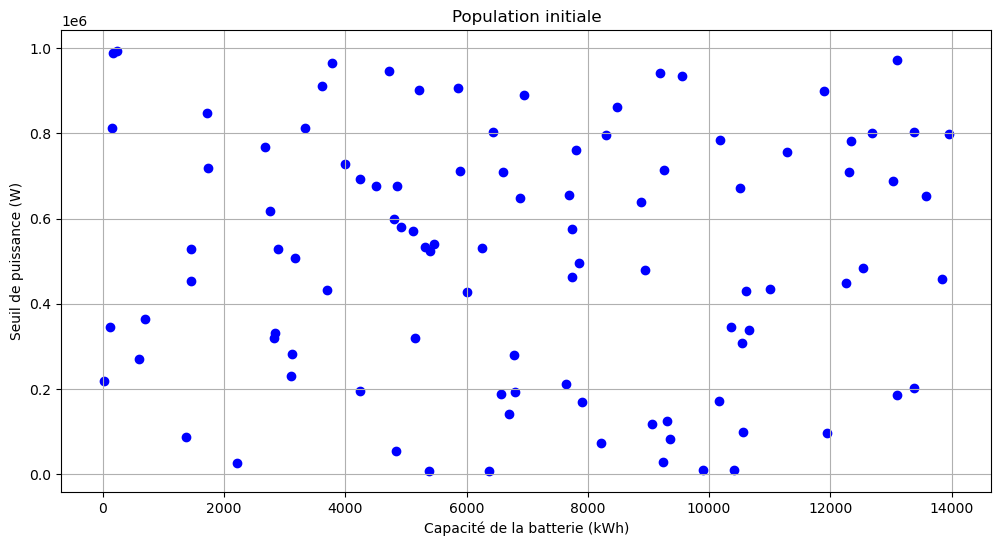

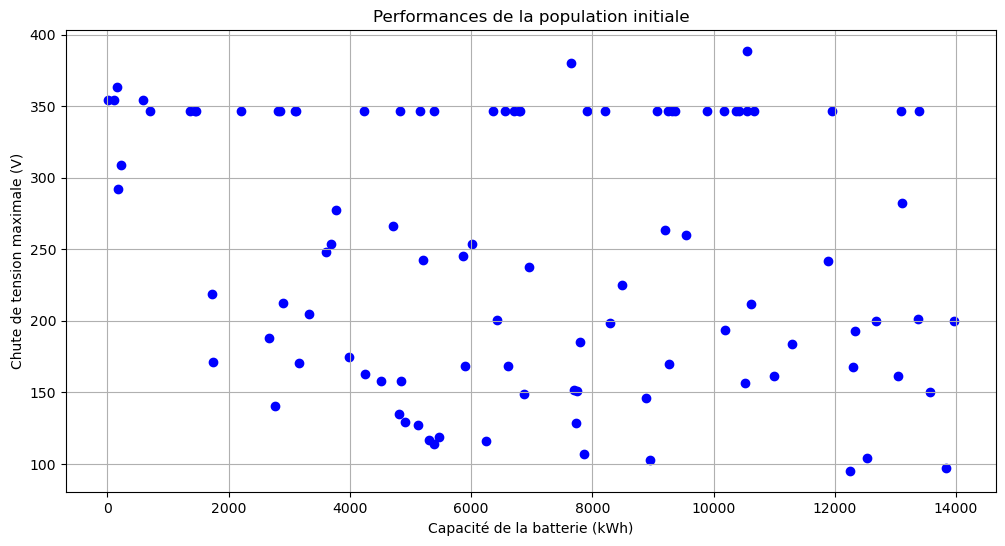

In [119]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la population initiale
population_size = 100  # Taille de la population
capacities = np.random.uniform(0, 14e3, population_size)  # Capacités des batteries (kWh)
seuils = np.random.uniform(0, 1e6, population_size)  # Seuils de puissance (W)

# Combinaison des gènes pour former les individus
population = np.column_stack((capacities, seuils))

# Visualisation de la population initiale
plt.figure(figsize=(12, 6))
plt.scatter(capacities, seuils, c='blue')
plt.xlabel('Capacité de la batterie (kWh)')
plt.ylabel('Seuil de puissance (W)')
plt.title('Population initiale')
plt.grid()
plt.show()


def evaluate_performance(individual, time, position, P_electrique_results):
    E_batterie = individual[0] * 1e3  # Convertir en Wh
    Seuil = individual[1]  # Seuil de puissance en W
    E_batterie_actuelle = E_batterie  # Capacité initiale de la batterie (Wh)
    delta_v_max = 0

    # Simulation temporelle
    for j in range(len(time)):
        x_pos = position[j]  # Position actuelle du train
        P_train = P_electrique_results[j]  # Puissance demandée par le train
        dt = time[j] - time[j - 1] if j > 0 else 1  # Delta de temps (approximation pour le premier point)

        if P_train < 0:  # Recharge (freinage)
            if E_batterie_actuelle < E_batterie:
                P_lac = 0  # Pas de puissance fournie par la sous-station
                P_rh = 0  # Rhéostat inactif
                P_batt = P_train  # Recharge de la batterie
                E_batterie_actuelle -= P_batt * dt * 0.9  # Prendre en compte le rendement de la batterie
            else:
                P_lac = 0
                P_batt = 0  # La batterie ne peut plus être chargée
                P_rh = -P_train  # Le rhéostat dissipe toute la puissance de freinage
        elif P_train >= 0:  # Décharge (consommation)
            if P_train <= Seuil:
                P_lac = P_train  # La sous-station fournit toute la puissance
                P_batt = 0  # Pas de décharge de la batterie
                P_rh = 0
            else:
                P_lac = Seuil  # La sous-station fournit au maximum jusqu'au seuil
                P_rh = 0
                if E_batterie_actuelle > 0:
                    P_batt = P_train - P_lac  # La batterie complète la puissance
                    # Limiter si l'énergie de la batterie est insuffisante
                    max_batt_power = E_batterie_actuelle * 0.9 / dt
                    if P_batt > max_batt_power:
                        P_batt = max_batt_power
                    E_batterie_actuelle -= P_batt * dt / 0.9  # Mise à jour de l'énergie de la batterie
                else:
                    P_batt = 0  # Batterie vide
                P_lac = P_train - P_batt  # Recalculer la puissance sous-station

        # Calcul des résistances des segments
        R_LAC1 = rho_LAC * x_pos  # Résistance de la première branche de la LAC
        R_rail1 = rho_rail * x_pos  # Résistance de la première branche des rails
        R_LAC2 = rho_LAC * (position[-1] - x_pos)  # Résistance de la deuxième branche de la LAC
        R_rail2 = rho_rail * (position[-1] - x_pos)  # Résistance de la deuxième branche des rails

        # Résistance équivalente de chaque branche
        R_haut = R_LAC1 + R_rail1 + R_internal
        R_bas = R_LAC2 + R_rail2 + R_internal
        R_eq = (R_haut * R_bas) / (R_haut + R_bas)  # Résistance équivalente

        # Calcul de la tension aux bornes du train
        discriminant = V_source**2 - 4 * R_eq * P_lac
        if discriminant >= 0:
            V_train = (V_source + np.sqrt(discriminant)) / 2
        else:
            V_train = 500  # Valeur par défaut si le discriminant est négatif

        delta_v = abs(V_source - V_train)
        if delta_v > delta_v_max:
            delta_v_max = delta_v

    return delta_v_max, individual[0]  # Retourne la chute de tension maximale et la capacité de la batterie

# Évaluation des performances de la population initiale
performances = np.array([evaluate_performance(individual, time, position, P_electrique_results) for individual in population])

# Visualisation des performances
plt.figure(figsize=(12, 6))
plt.scatter(performances[:, 1], performances[:, 0], c='blue')
plt.xlabel('Capacité de la batterie (kWh)')
plt.ylabel('Chute de tension maximale (V)')
plt.title('Performances de la population initiale')
plt.grid()
plt.show()


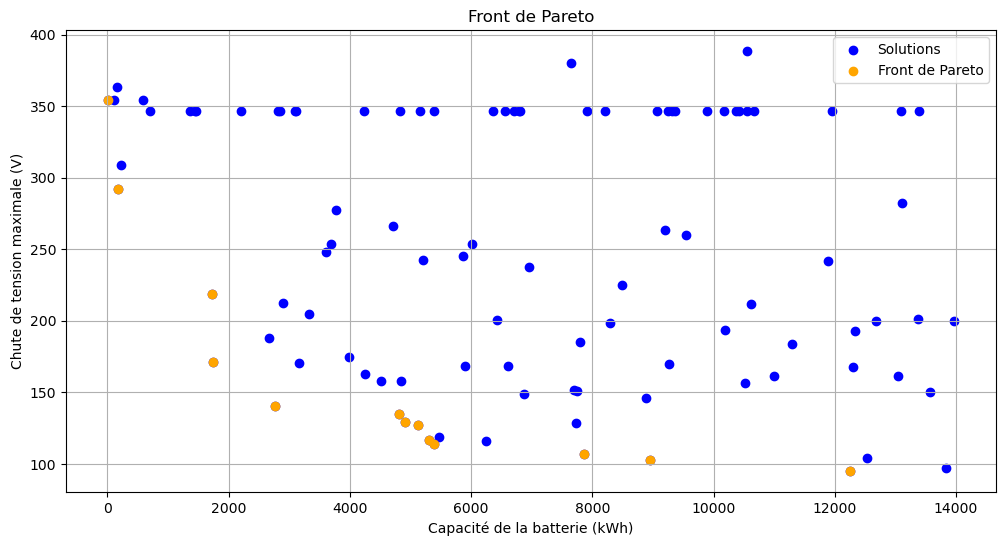

In [120]:
def is_dominated(candidate, pareto_front):
    for point in pareto_front:
        if (point[0] <= candidate[0] and point[1] <= candidate[1]) and (point[0] < candidate[0] or point[1] < candidate[1]):
            return True
    return False

# Sélection des individus non dominés
pareto_front = []
for performance in performances:
    candidate = (performance[1], performance[0])  # (capacité, chute de tension maximale)
    if not is_dominated(candidate, pareto_front):
        pareto_front.append(candidate)
        pareto_front = [point for point in pareto_front if not is_dominated(point, [candidate])]

# Séparation des points du front de Pareto
pareto_capacities = [point[0] for point in pareto_front]
pareto_delta_v_max = [point[1] for point in pareto_front]

# Visualisation du front de Pareto
plt.figure(figsize=(12, 6))
plt.scatter(performances[:, 1], performances[:, 0], c='blue', label='Solutions')
plt.scatter(pareto_capacities, pareto_delta_v_max, c='orange', label='Front de Pareto')
plt.xlabel('Capacité de la batterie (kWh)')
plt.ylabel('Chute de tension maximale (V)')
plt.title('Front de Pareto')
plt.legend()
plt.grid()
plt.show()


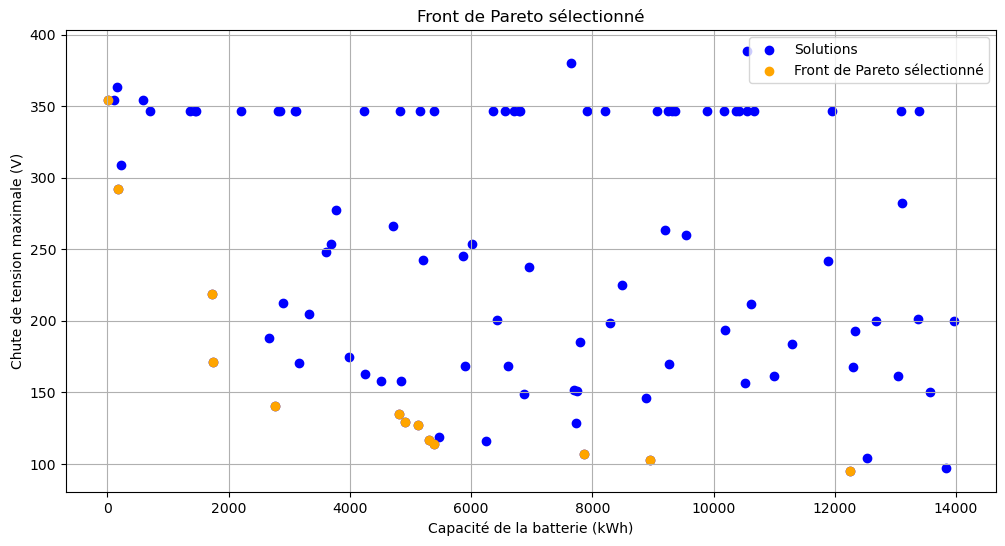

In [121]:
def select_best_individuals(performances, population_size):
    # Sélection des individus non dominés
    pareto_front = []
    for performance in performances:
        candidate = (performance[1], performance[0])  # (capacité, chute de tension maximale)
        if not is_dominated(candidate, pareto_front):
            pareto_front.append(candidate)
            pareto_front = [point for point in pareto_front if not is_dominated(point, [candidate])]

    # Séparation des points du front de Pareto
    pareto_capacities = [point[0] for point in pareto_front]
    pareto_delta_v_max = [point[1] for point in pareto_front]

    # Calcul des distances pour éviter les solutions trop proches
    distances = np.zeros(len(pareto_front))
    for i in range(len(pareto_front)):
        for j in range(len(pareto_front)):
            if i != j:
                distances[i] += np.linalg.norm(np.array(pareto_front[i]) - np.array(pareto_front[j]))

    # Sélection des 50% meilleurs individus en fonction de leur rang et de leur distance
    selected_indices = np.argsort(distances)[-population_size//2:]
    selected_pareto_front = [pareto_front[i] for i in selected_indices]

    return selected_pareto_front

# Sélection des meilleurs individus
selected_pareto_front = select_best_individuals(performances, population_size)

# Séparation des points du front de Pareto sélectionnés
selected_pareto_capacities = [point[0] for point in selected_pareto_front]
selected_pareto_delta_v_max = [point[1] for point in selected_pareto_front]

# Visualisation du front de Pareto sélectionné
plt.figure(figsize=(12, 6))
plt.scatter(performances[:, 1], performances[:, 0], c='blue', label='Solutions')
plt.scatter(selected_pareto_capacities, selected_pareto_delta_v_max, c='orange', label='Front de Pareto sélectionné')
plt.xlabel('Capacité de la batterie (kWh)')
plt.ylabel('Chute de tension maximale (V)')
plt.title('Front de Pareto sélectionné')
plt.legend()
plt.grid()
plt.show()


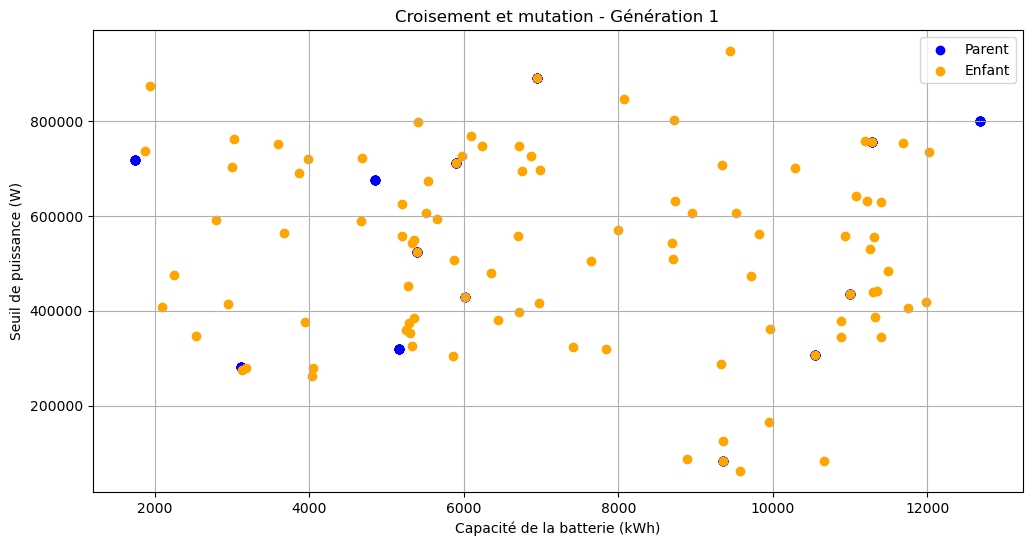

In [122]:
# Fonction de croisement
def crossover(parent1, parent2):
    alpha = np.random.uniform(-0.1, 1.1)
    beta = np.random.uniform(-0.1, 1.1)
    child = np.zeros(2)
    child[0] = alpha * parent1[0] + (1 - alpha) * parent2[0]
    child[1] = beta * parent1[1] + (1 - beta) * parent2[1]
    return child

# Fonction de mutation
def mutate(individual, mutation_rate=0.01):
    if np.random.rand() < mutation_rate:
        individual[0] += np.random.uniform(-1e3, 1e3)  # Mutation de la capacité
    if np.random.rand() < mutation_rate:
        individual[1] += np.random.uniform(-1e5, 1e5)  # Mutation du seuil de puissance
    return individual

# Croisement et mutation pour créer une nouvelle population
new_population = []
parents = []
children = []

for i in range(len(pareto_front) // 2):
    parent1 = population[np.random.randint(len(pareto_front))]
    parent2 = population[np.random.randint(len(pareto_front))]
    parents.append(parent1)
    parents.append(parent2)
    child = crossover(parent1, parent2)
    child = mutate(child)
    children.append(child)
    new_population.append(child)

# Compléter la population pour atteindre la taille initiale
while len(new_population) < population_size:
    parent1 = population[np.random.randint(len(pareto_front))]
    parent2 = population[np.random.randint(len(pareto_front))]
    parents.append(parent1)
    parents.append(parent2)
    child = crossover(parent1, parent2)
    child = mutate(child)
    children.append(child)
    new_population.append(child)

population = np.array(new_population)

# Conversion des listes en arrays pour la visualisation
parents = np.array(parents)
children = np.array(children)

# Visualisation des parents et des enfants
plt.figure(figsize=(12, 6))
plt.scatter(parents[:, 0], parents[:, 1], c='blue', label='Parent')
plt.scatter(children[:, 0], children[:, 1], c='orange', label='Enfant')
plt.xlabel('Capacité de la batterie (kWh)')
plt.ylabel('Seuil de puissance (W)')
plt.title('Croisement et mutation - Génération 1')
plt.legend()
plt.grid()
plt.show()


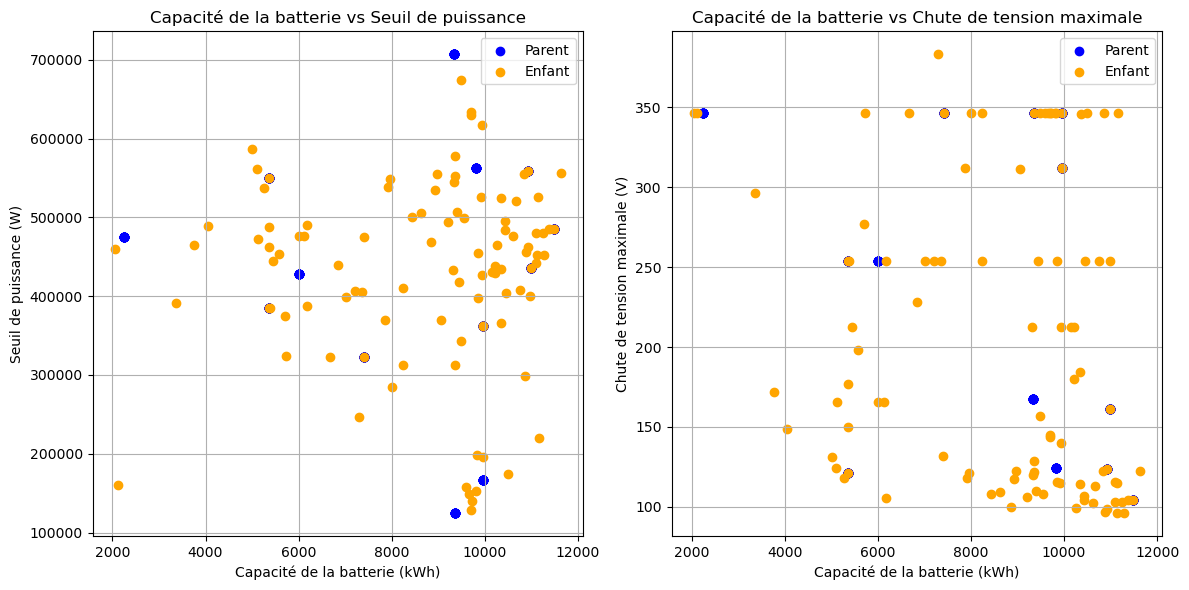

In [125]:
import numpy as np
import matplotlib.pyplot as plt

# Fonction de croisement
def crossover(parent1, parent2):
    alpha = np.random.uniform(-0.1, 1.1)
    beta = np.random.uniform(-0.1, 1.1)
    child = np.zeros(2)
    child[0] = alpha * parent1[0] + (1 - alpha) * parent2[0]
    child[1] = beta * parent1[1] + (1 - beta) * parent2[1]
    return child

# Fonction de mutation
def mutate(individual, mutation_rate=0.01):
    if np.random.rand() < mutation_rate:
        individual[0] += np.random.uniform(-1e3, 1e3)  # Mutation de la capacité
    if np.random.rand() < mutation_rate:
        individual[1] += np.random.uniform(-1e5, 1e5)  # Mutation du seuil de puissance
    return individual

# Fonction d'évaluation des performances
def evaluate_performance(individual, time, position, P_electrique_results):
    E_batterie = individual[0] * 1e3  # Convertir en Wh
    Seuil = individual[1]  # Seuil de puissance en W
    E_batterie_actuelle = E_batterie  # Capacité initiale de la batterie (Wh)
    delta_v_max = 0

    # Simulation temporelle
    for j in range(len(time)):
        x_pos = position[j]  # Position actuelle du train
        P_train = P_electrique_results[j]  # Puissance demandée par le train
        dt = time[j] - time[j - 1] if j > 0 else 1  # Delta de temps (approximation pour le premier point)

        if P_train < 0:  # Recharge (freinage)
            if E_batterie_actuelle < E_batterie:
                P_lac = 0  # Pas de puissance fournie par la sous-station
                P_rh = 0  # Rhéostat inactif
                P_batt = P_train  # Recharge de la batterie
                E_batterie_actuelle -= P_batt * dt * 0.9  # Prendre en compte le rendement de la batterie
            else:
                P_lac = 0
                P_batt = 0  # La batterie ne peut plus être chargée
                P_rh = -P_train  # Le rhéostat dissipe toute la puissance de freinage
        elif P_train >= 0:  # Décharge (consommation)
            if P_train <= Seuil:
                P_lac = P_train  # La sous-station fournit toute la puissance
                P_batt = 0  # Pas de décharge de la batterie
                P_rh = 0
            else:
                P_lac = Seuil  # La sous-station fournit au maximum jusqu'au seuil
                P_rh = 0
                if E_batterie_actuelle > 0:
                    P_batt = P_train - P_lac  # La batterie complète la puissance
                    # Limiter si l'énergie de la batterie est insuffisante
                    max_batt_power = E_batterie_actuelle * 0.9 / dt
                    if P_batt > max_batt_power:
                        P_batt = max_batt_power
                    E_batterie_actuelle -= P_batt * dt / 0.9  # Mise à jour de l'énergie de la batterie
                else:
                    P_batt = 0  # Batterie vide
                P_lac = P_train - P_batt  # Recalculer la puissance sous-station

        # Calcul des résistances des segments
        R_LAC1 = rho_LAC * x_pos  # Résistance de la première branche de la LAC
        R_rail1 = rho_rail * x_pos  # Résistance de la première branche des rails
        R_LAC2 = rho_LAC * (position[-1] - x_pos)  # Résistance de la deuxième branche de la LAC
        R_rail2 = rho_rail * (position[-1] - x_pos)  # Résistance de la deuxième branche des rails

        # Résistance équivalente de chaque branche
        R_haut = R_LAC1 + R_rail1 + R_internal
        R_bas = R_LAC2 + R_rail2 + R_internal
        R_eq = (R_haut * R_bas) / (R_haut + R_bas)  # Résistance équivalente

        # Calcul de la tension aux bornes du train
        discriminant = V_source**2 - 4 * R_eq * (P_lac)
        if discriminant >= 0:
            V_train = (V_source + np.sqrt(discriminant)) / 2
        else:
            V_train = 500  # Valeur par défaut si le discriminant est négatif

        delta_v = abs(V_source - V_train)
        if delta_v > delta_v_max:
            delta_v_max = delta_v

    return delta_v_max, individual[0], individual[1]  # Retourne la chute de tension maximale, la capacité de la batterie et le seuil de puissance

# Croisement et mutation pour créer une nouvelle population
new_population = []
parents = []
children = []

for i in range(len(pareto_front) // 2):
    parent1 = population[np.random.randint(len(pareto_front))]
    parent2 = population[np.random.randint(len(pareto_front))]
    parents.append(parent1)
    parents.append(parent2)
    child = crossover(parent1, parent2)
    child = mutate(child)
    children.append(child)
    new_population.append(child)

# Compléter la population pour atteindre la taille initiale
while len(new_population) < population_size:
    parent1 = population[np.random.randint(len(pareto_front))]
    parent2 = population[np.random.randint(len(pareto_front))]
    parents.append(parent1)
    parents.append(parent2)
    child = crossover(parent1, parent2)
    child = mutate(child)
    children.append(child)
    new_population.append(child)

population = np.array(new_population)

# Conversion des listes en arrays pour la visualisation
parents = np.array(parents)
children = np.array(children)

# Évaluation des performances des parents
parent_performances = np.array([evaluate_performance(parent, time, position, P_electrique_results) for parent in parents])

# Évaluation des performances des enfants
child_performances = np.array([evaluate_performance(child, time, position, P_electrique_results) for child in children])

# Visualisation des parents et des enfants en termes de capacité de la batterie et de seuil de puissance
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(parent_performances[:, 1], parent_performances[:, 2], c='blue', label='Parent')
plt.scatter(child_performances[:, 1], child_performances[:, 2], c='orange', label='Enfant')
plt.xlabel('Capacité de la batterie (kWh)')
plt.ylabel('Seuil de puissance (W)')
plt.title('Capacité de la batterie vs Seuil de puissance')
plt.legend()
plt.grid()

# Visualisation des parents et des enfants en termes de capacité de la batterie et de chute de tension maximale
plt.subplot(1, 2, 2)
plt.scatter(parent_performances[:, 1], parent_performances[:, 0], c='blue', label='Parent')
plt.scatter(child_performances[:, 1], child_performances[:, 0], c='orange', label='Enfant')
plt.xlabel('Capacité de la batterie (kWh)')
plt.ylabel('Chute de tension maximale (V)')
plt.title('Capacité de la batterie vs Chute de tension maximale')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# 3.4 Résolution par algorithme génétique

Les algorithmes génétiques sont des méthodes d'optimisation inspirées par les processus de sélection naturelle et de génétique. Ils sont particulièrement adaptés pour les problèmes d'optimisation multi-objectifs car ils permettent de trouver un ensemble de solutions non dominées, c'est-à-dire des solutions qui ne sont pas pires que les autres sur tous les objectifs.

## Principe de base

### Population initiale
On commence par générer une population initiale de solutions aléatoires dans l'espace de recherche. Chaque solution est appelée un "individu" et est caractérisée par ses "gènes", qui sont les variables de décision du problème.

### Évaluation des performances
Pour chaque individu de la population, on calcule ses performances en termes des objectifs à optimiser (coût de la batterie et chute de tension maximale dans ton cas).

### Sélection
On sélectionne les individus les plus performants pour former la nouvelle génération. Les individus sont classés par rang de dominance (rang 1 : solutions non dominées, rang 2 : solutions non dominées après avoir enlevé les solutions de rang 1, etc.). On utilise également un critère de distance pour éviter d'avoir des solutions trop proches les unes des autres, ce qui permet de couvrir au mieux le front de Pareto.

### Croisement et mutation
On crée de nouveaux individus par croisement des individus sélectionnés. Le croisement consiste à combiner les gènes de deux parents pour créer un nouvel individu. On peut également appliquer des mutations pour introduire de la diversité dans la population.

### Répétition
On répète les étapes d'évaluation, de sélection, de croisement et de mutation pour un certain nombre de générations jusqu'à ce que les solutions convergent vers le front de Pareto.

## Étapes détaillées

### Tirage aléatoire d'une population de départ
Générer une population initiale de 50 à 100 individus. Chaque individu est représenté par ses gènes, qui sont les variables de décision (capacité de la batterie et seuil de commande dans ton cas).

### Calcul des performances
Pour chaque individu, simuler le trajet du train et calculer les objectifs (coût de la batterie et chute de tension maximale).

### Calcul du rang des individus
Classer les individus par rang de dominance. Les individus de rang 1 sont les solutions non dominées. Les individus de rang 2 sont les solutions non dominées après avoir enlevé les solutions de rang 1, et ainsi de suite.

### Sélection des meilleurs individus
Sélectionner les 50% meilleurs individus en fonction de leur rang et de leur distance pour éviter d'avoir des solutions trop proches.

### Création de nouveaux individus
Créer de nouveaux individus par croisement des individus sélectionnés. Le croisement peut être fait par combinaison linéaire des gènes des parents avec un facteur de pondération aléatoire. On peut également appliquer des mutations pour introduire de la diversité.

### Répétition
Répéter les étapes d'évaluation, de sélection, de croisement et de mutation pour un certain nombre de générations.

## Croisement (Crossover)
Le croisement est un processus par lequel deux individus (appelés "parents" ou "individus") échangent des informations génétiques pour produire un ou plusieurs nouveaux individus (appelés "enfants" ou "nouveaux individus"). L'objectif est de combiner les caractéristiques des parents pour potentiellement créer des individus plus performants.

Dans notre cas, chaque individu est représenté par deux gènes: la capacité de la batterie et le seuil de puissance. Voici comment fonctionne le croisement:

1. **Sélection des parents**: Deux individus sont sélectionnés aléatoirement parmi la population.
2. **Combinaison des gènes**: Les gènes des deux parents sont combinés pour créer un nouvel individu. Une manière simple de le faire est d'utiliser une combinaison linéaire des gènes des parents avec des facteurs de pondération aléatoires.

## Mutation
La mutation est un processus par lequel un individu subit une modification aléatoire de ses gènes. L'objectif est d'introduire de la diversité dans la population et d'explorer de nouvelles régions de l'espace de recherche. La mutation permet d'éviter que la population ne converge trop rapidement vers une solution locale.

Voici comment fonctionne la mutation:

1. **Sélection de l'individu**: Un individu est sélectionné pour subir une mutation.
2. **Modification des gènes**: Les gènes de l'individu sont modifiés de manière aléatoire. Par exemple, on peut ajouter une petite valeur aléatoire à la capacité de la batterie et au seuil de puissance.

## Conclusion
Les algorithmes génétiques sont puissants pour résoudre des problèmes d'optimisation multi-objectifs car ils permettent de trouver un ensemble de solutions non dominées. En suivant les étapes décrites ci-dessus, tu devrais être en mesure d'implémenter un algorithme génétique pour ton projet et obtenir des résultats similaires à ceux obtenus avec la méthode de Monte Carlo, mais avec une meilleure représentation du front de Pareto.

une meilleure représentation du front de Pareto.

similaires à ceux obtenus avec la méthode de Monte Carlo, mais avec une meilleure représentation du front de Pareto.

# Programme principal 

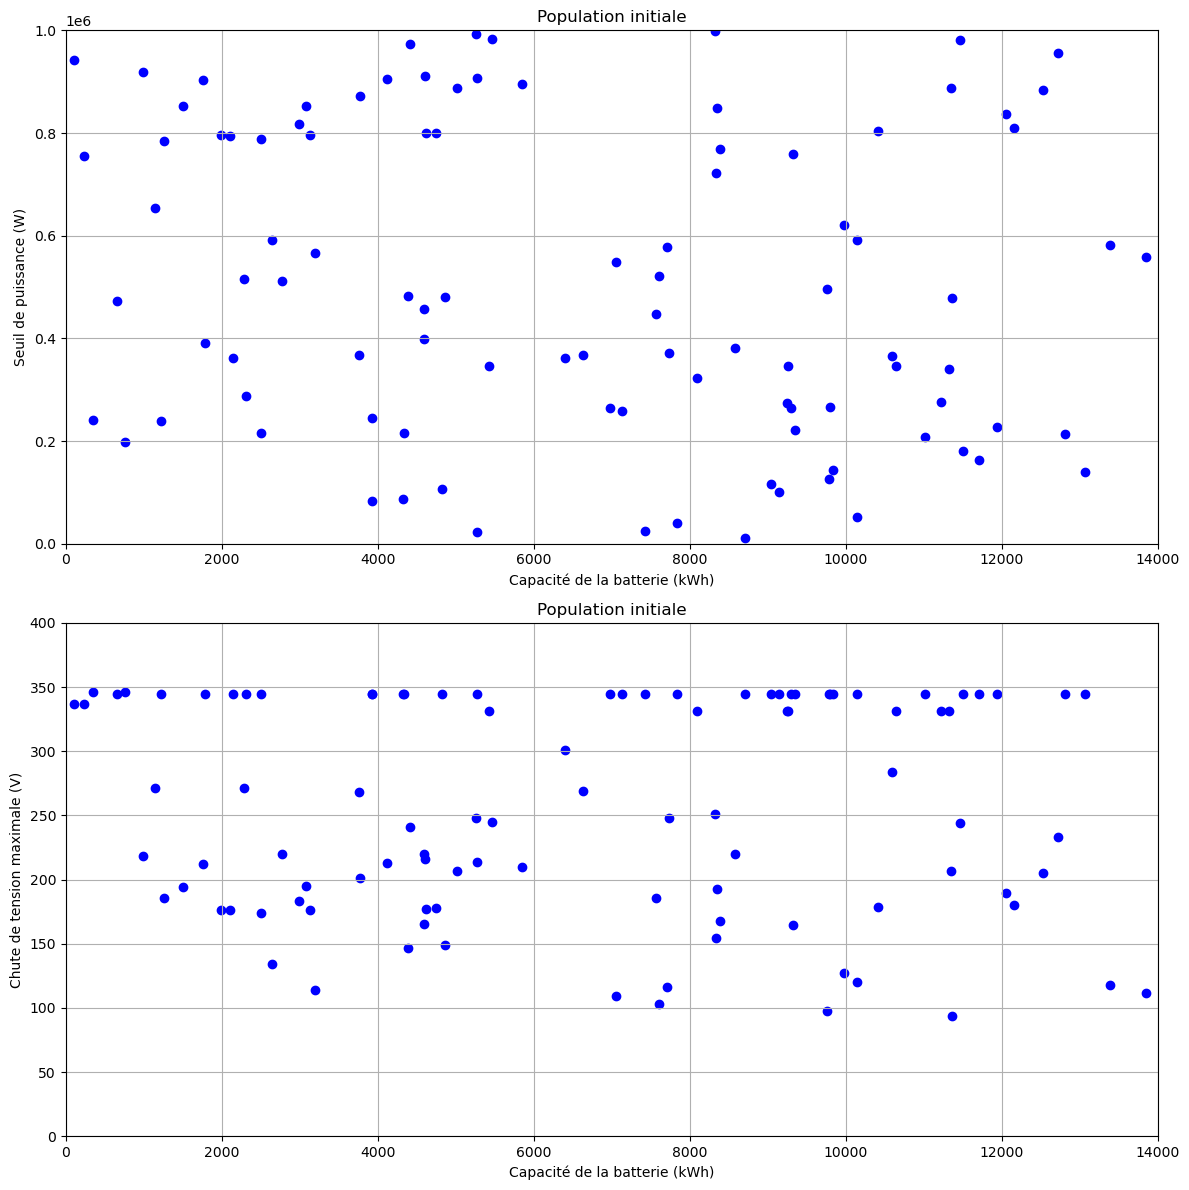

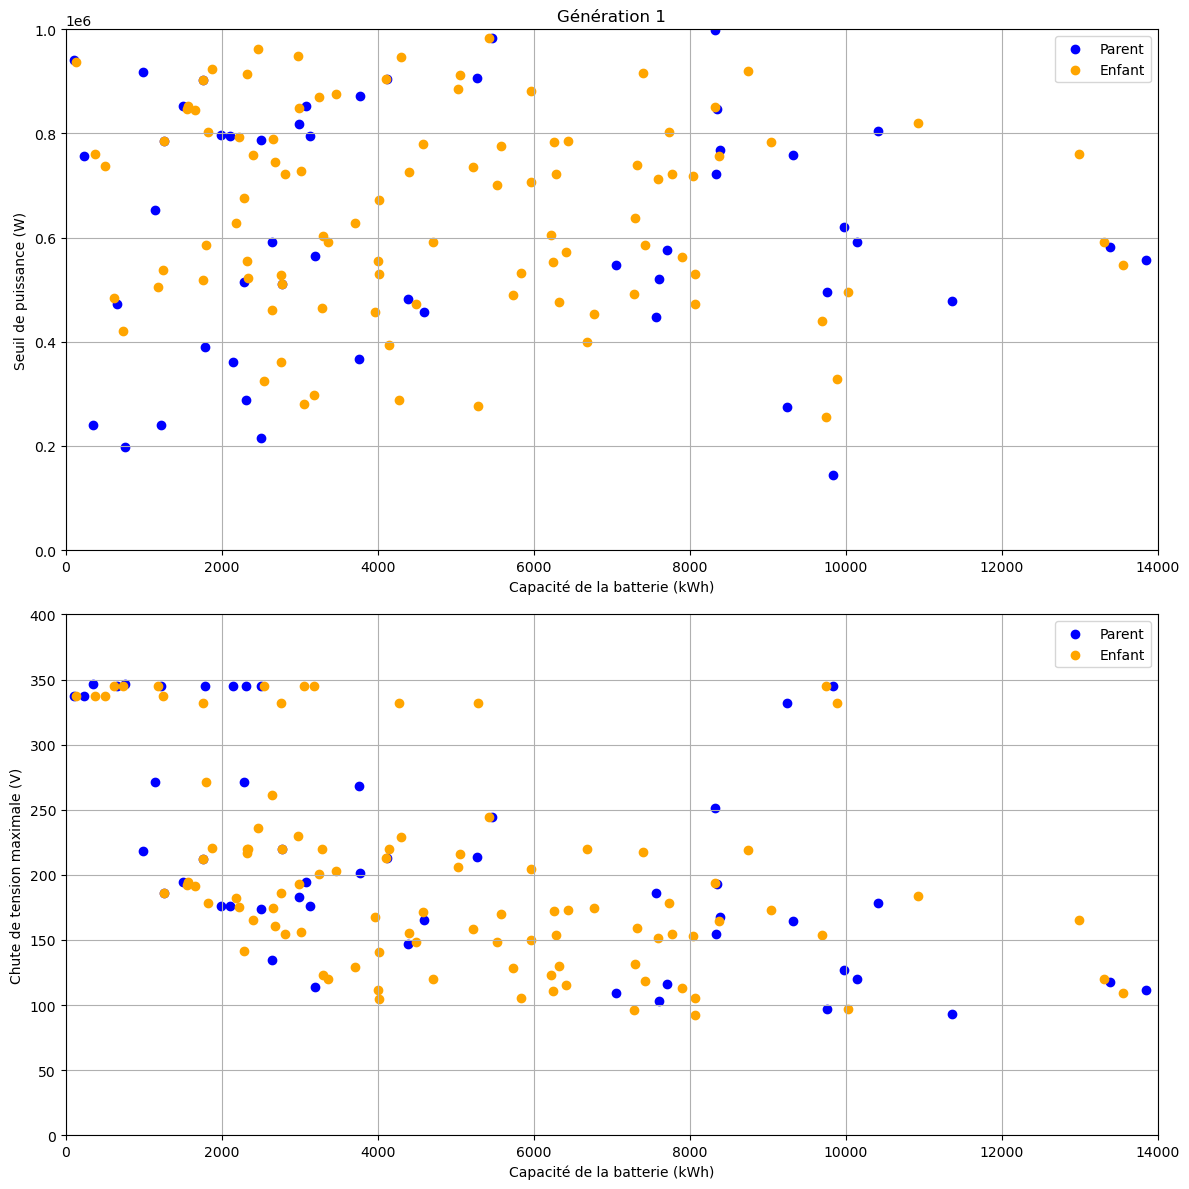

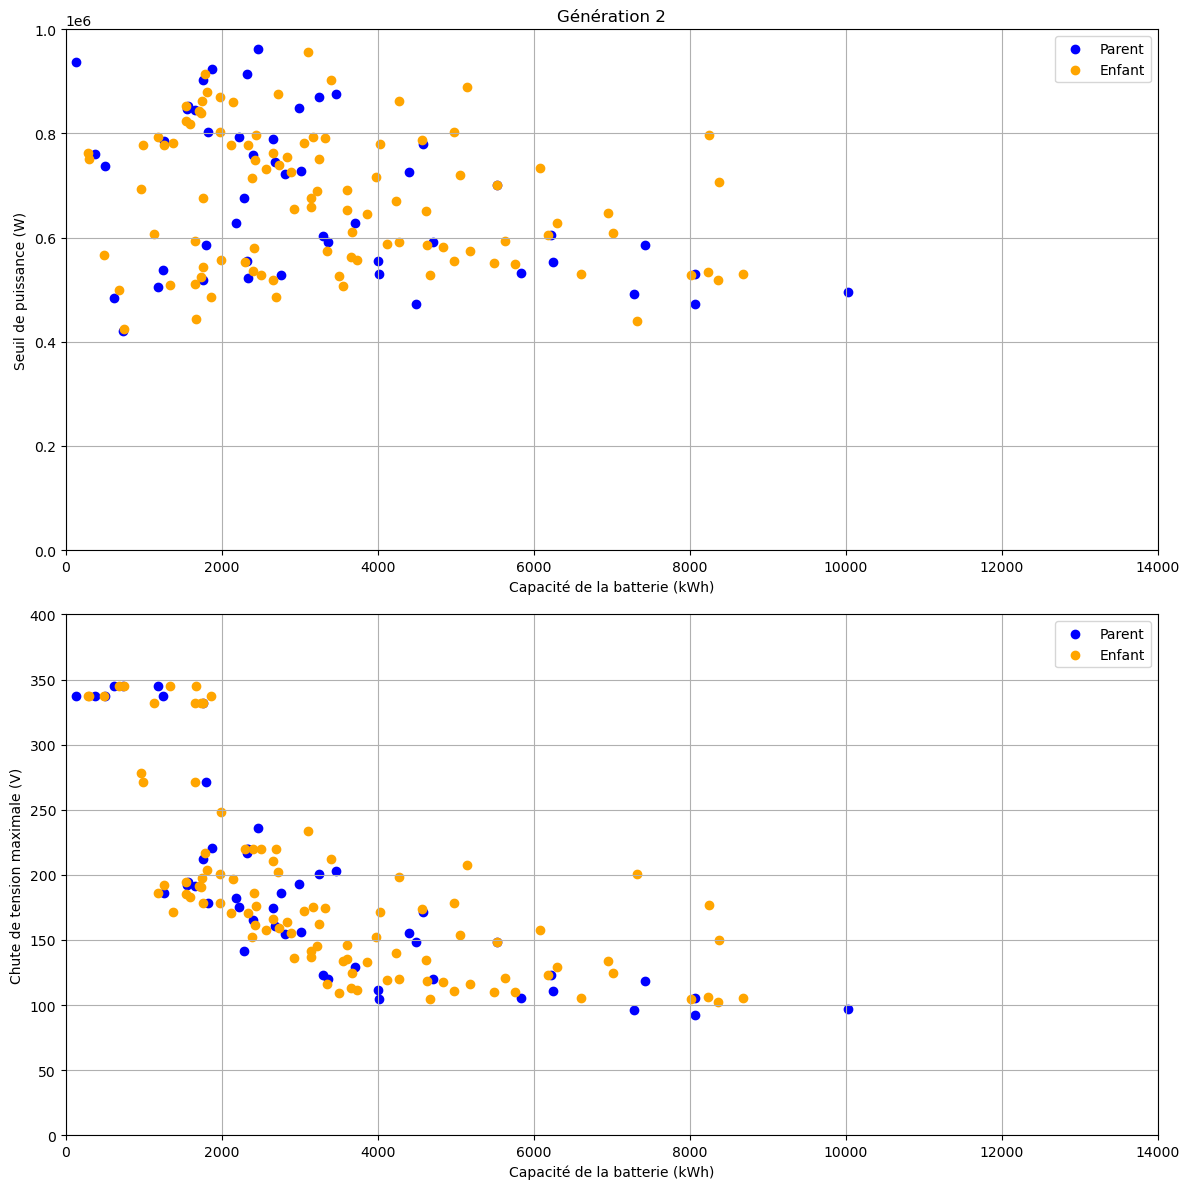

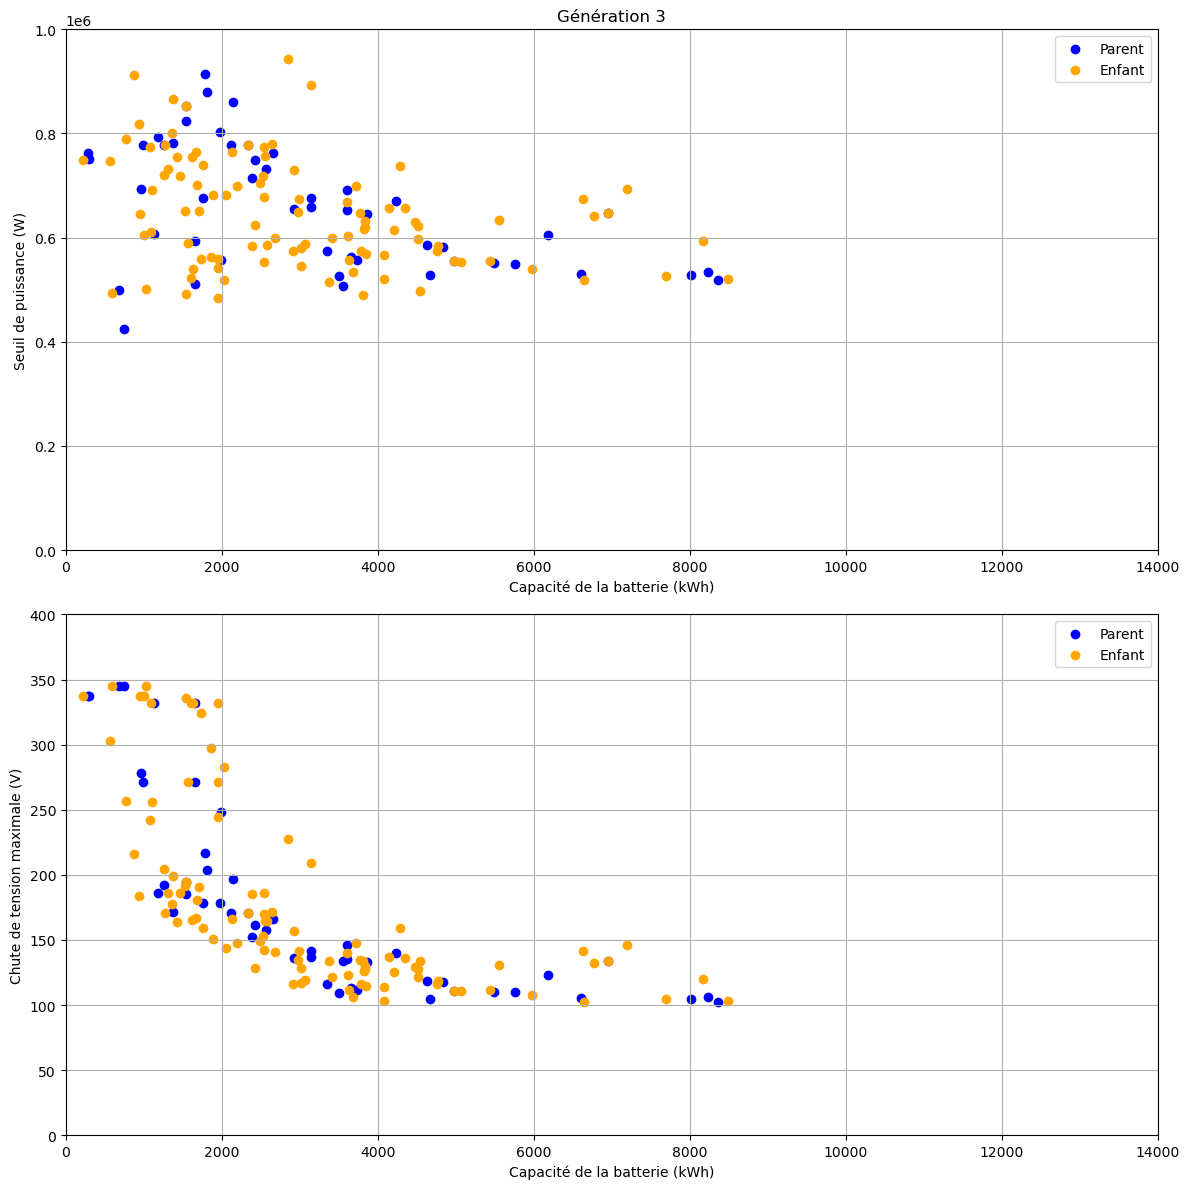

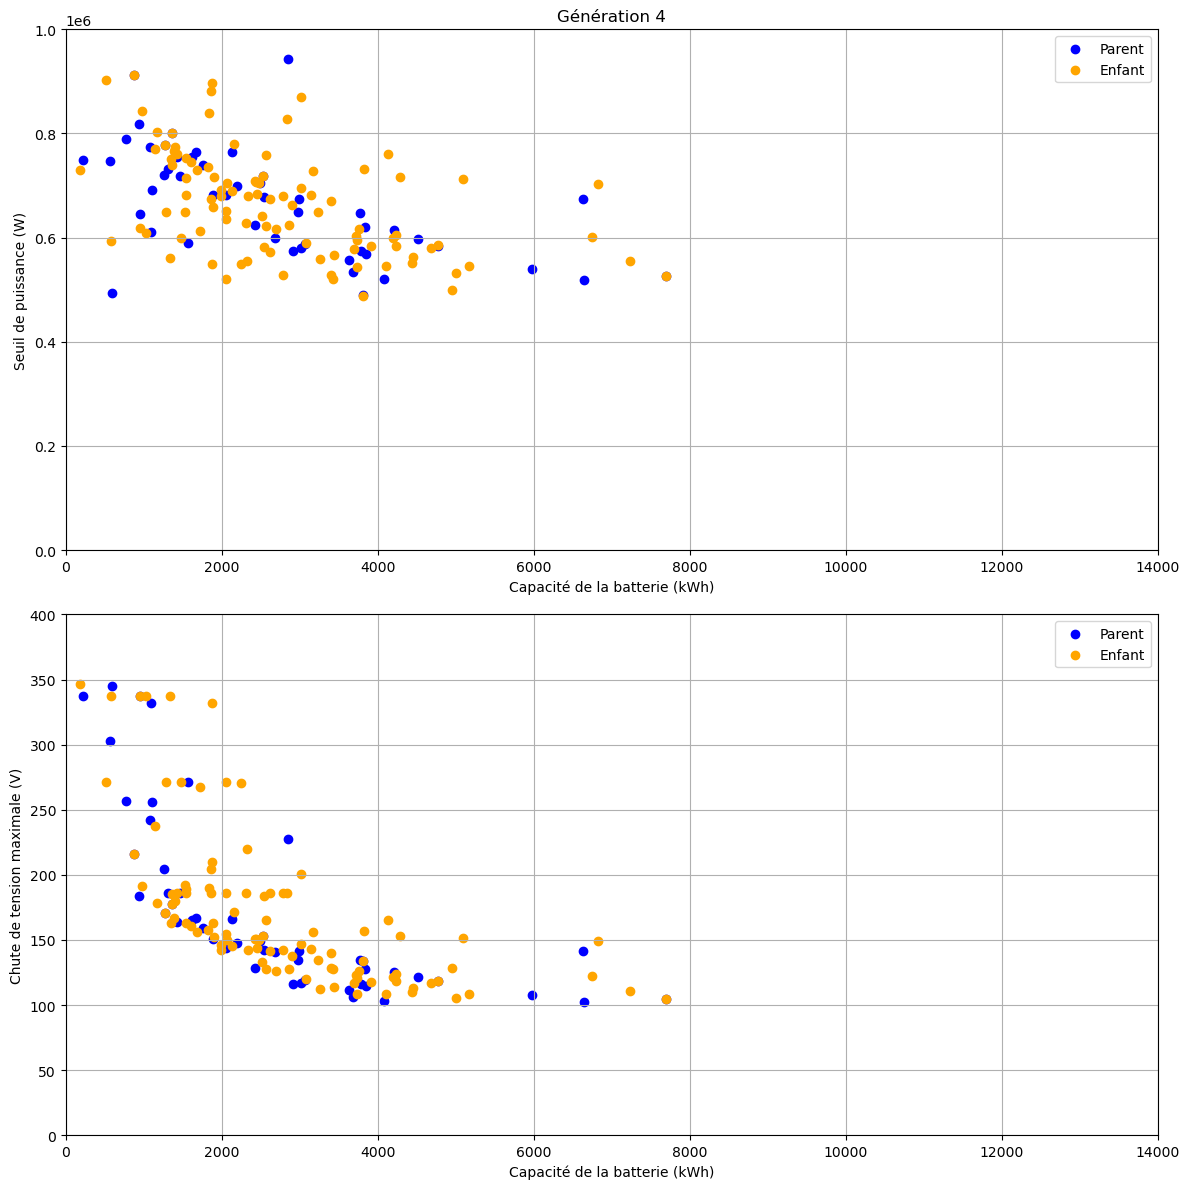

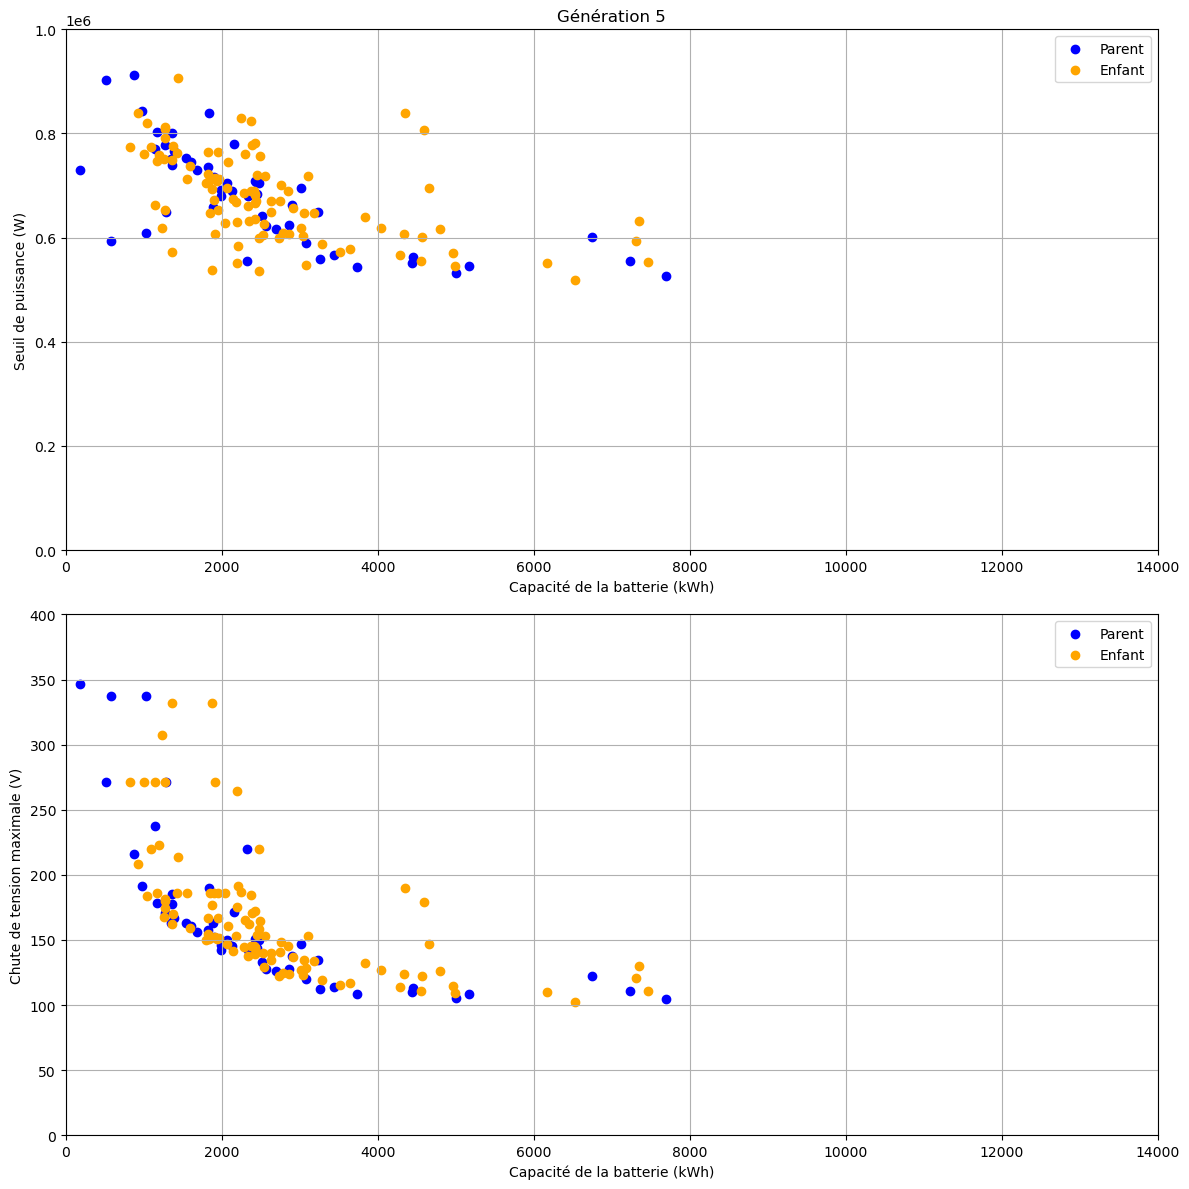

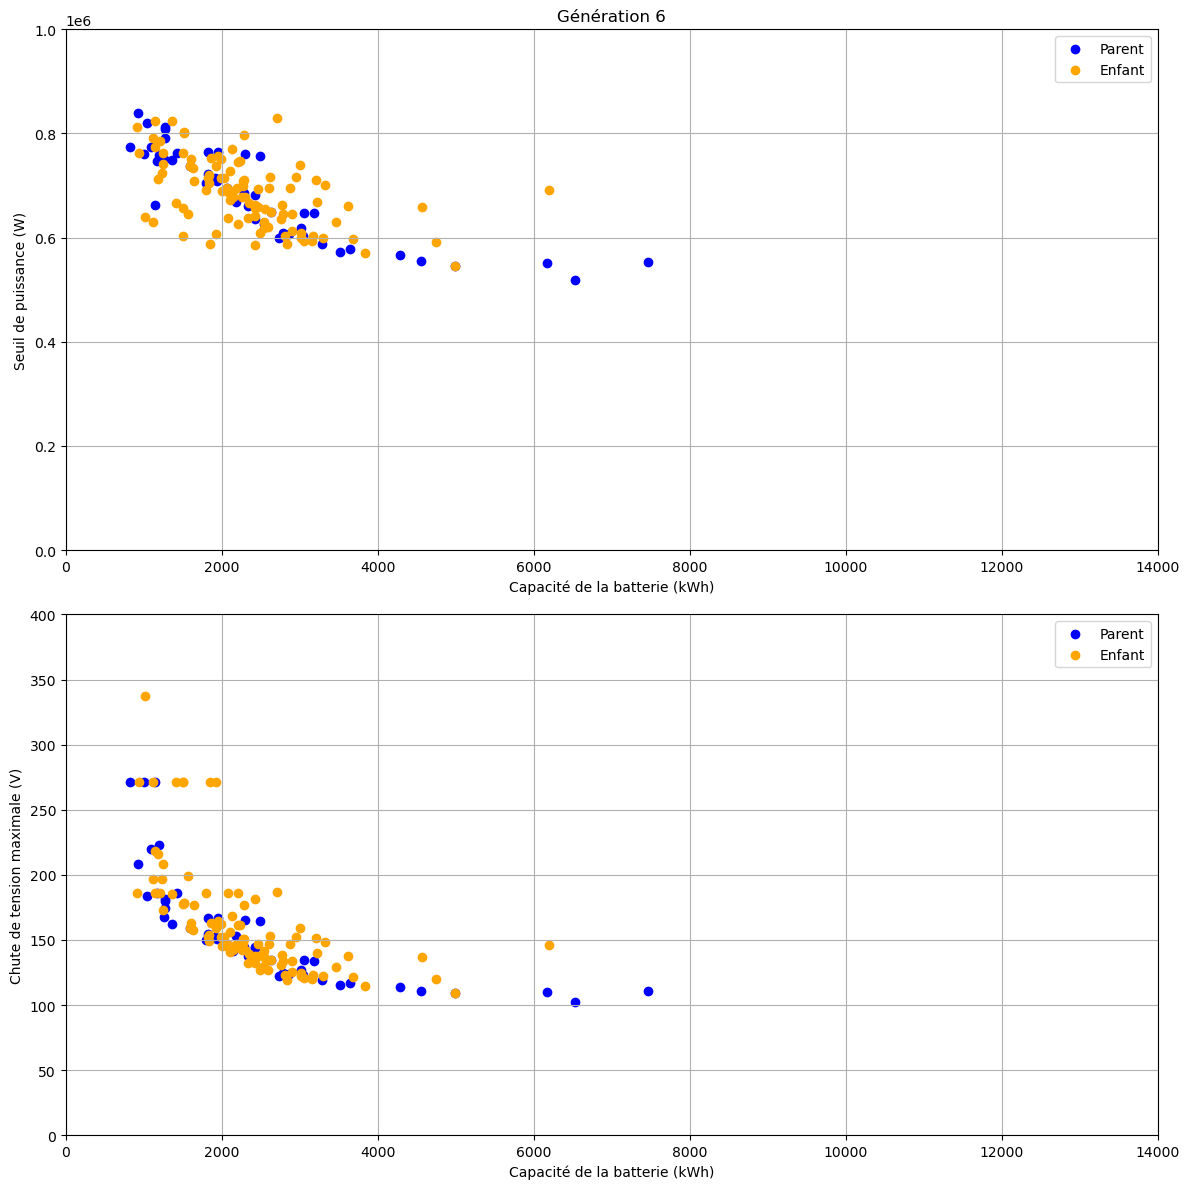

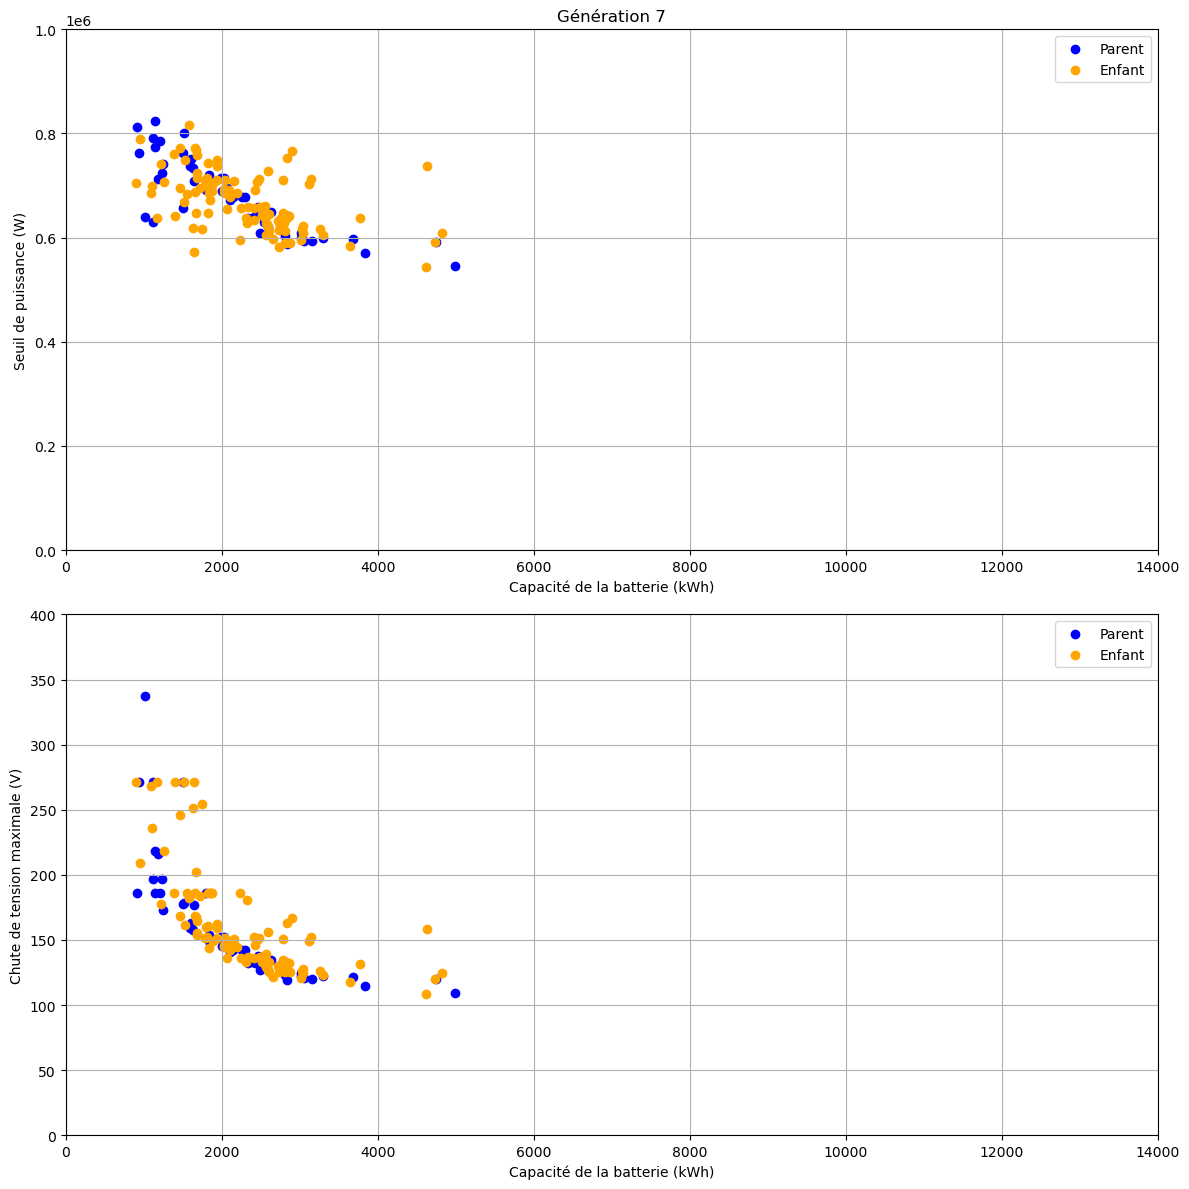

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la batterie
rho_LAC = 95e-6  # Résistance linéique de la LAC (Ohm/m)
rho_rail = 10e-6  # Résistance linéique des rails (Ohm/m)
R_internal = 0.01  # Résistance interne de la sous-station (Ohm)
V_source = 790  # Tension de la sous-station (V)

# Fonction de croisement
def crossover(parent1, parent2):
    alpha = np.random.uniform(-0.1, 1.1)
    beta = np.random.uniform(-0.1, 1.1)
    child = np.zeros(2)
    child[0] = alpha * parent1[0] + (1 - alpha) * parent2[0]
    child[1] = beta * parent1[1] + (1 - beta) * parent2[1]
    return child

# Fonction de mutation
def mutate(individual, mutation_rate=0.01):
    if np.random.rand() < mutation_rate:
        individual[0] += np.random.uniform(-1e3, 1e3)  # Mutation de la capacité
    if np.random.rand() < mutation_rate:
        individual[1] += np.random.uniform(-1e5, 1e5)  # Mutation du seuil de puissance
    return individual

# Fonction d'évaluation des performances
def evaluate_performance(individual, time, position, P_electrique_results):
    E_batterie = individual[0] * 1e3  # Convertir en Wh
    Seuil = individual[1]  # Seuil de puissance en W
    E_batterie_actuelle = E_batterie  # Capacité initiale de la batterie (Wh)
    delta_v_max = 0

    # Simulation temporelle
    for j in range(len(time)):
        x_pos = position[j]  # Position actuelle du train
        P_train = P_electrique_results[j]  # Puissance demandée par le train
        dt = time[j] - time[j - 1] if j > 0 else 1  # Delta de temps (approximation pour le premier point)

        if P_train < 0:  # Recharge (freinage)
            if E_batterie_actuelle < E_batterie:
                P_lac = 0  # Pas de puissance fournie par la sous-station
                P_rh = 0  # Rhéostat inactif
                P_batt = P_train  # Recharge de la batterie
                E_batterie_actuelle -= P_batt * dt * 0.9  # Prendre en compte le rendement de la batterie
            else:
                P_lac = 0
                P_batt = 0  # La batterie ne peut plus être chargée
                P_rh = -P_train  # Le rhéostat dissipe toute la puissance de freinage
        elif P_train >= 0:  # Décharge (consommation)
            if P_train <= Seuil:
                P_lac = P_train  # La sous-station fournit toute la puissance
                P_batt = 0  # Pas de décharge de la batterie
                P_rh = 0
            else:
                P_lac = Seuil  # La sous-station fournit au maximum jusqu'au seuil
                P_rh = 0
                if E_batterie_actuelle > 0:
                    P_batt = P_train - P_lac  # La batterie complète la puissance
                    # Limiter si l'énergie de la batterie est insuffisante
                    max_batt_power = E_batterie_actuelle * 0.9 / dt
                    if P_batt > max_batt_power:
                        P_batt = max_batt_power
                    E_batterie_actuelle -= P_batt * dt / 0.9  # Mise à jour de l'énergie de la batterie
                else:
                    P_batt = 0  # Batterie vide
                P_lac = P_train - P_batt  # Recalculer la puissance sous-station

        # Calcul des résistances des segments
        R_LAC1 = rho_LAC * x_pos  # Résistance de la première branche de la LAC
        R_rail1 = rho_rail * x_pos  # Résistance de la première branche des rails
        R_LAC2 = rho_LAC * (position[-1] - x_pos)  # Résistance de la deuxième branche de la LAC
        R_rail2 = rho_rail * (position[-1] - x_pos)  # Résistance de la deuxième branche des rails

        # Résistance équivalente de chaque branche
        R_haut = R_LAC1 + R_rail1 + R_internal
        R_bas = R_LAC2 + R_rail2 + R_internal
        R_eq = (R_haut * R_bas) / (R_haut + R_bas)  # Résistance équivalente

        # Calcul de la tension aux bornes du train
        discriminant = V_source**2 - 4 * R_eq * (P_lac)
        if discriminant >= 0:
            V_train = (V_source + np.sqrt(discriminant)) / 2
        else:
            V_train = 500  # Valeur par défaut si le discriminant est négatif

        delta_v = abs(V_source - V_train)
        if delta_v > delta_v_max:
            delta_v_max = delta_v

    return delta_v_max, individual[0], individual[1]  # Retourne la chute de tension maximale, la capacité de la batterie et le seuil de puissance

# Fonction pour vérifier si un individu est dominé
def is_dominated(candidate, pareto_front):
    for point in pareto_front:
        if (point[0] <= candidate[0] and point[1] <= candidate[1]) and (point[0] < candidate[0] or point[1] < candidate[1]):
            return True
    return False

# Fonction pour le tri non dominé
def non_dominated_sorting(population):
    pareto_fronts = []
    while len(population) > 0:
        pareto_front = []
        for individual in population:
            if not is_dominated(individual, pareto_front):
                pareto_front.append(individual)
        pareto_fronts.append(pareto_front)
        population = [ind for ind in population if not any(np.all(ind == pf) for pf in pareto_front)]
    return pareto_fronts

# Fonction pour assigner les rangs
def assign_ranks(population):
    pareto_fronts = non_dominated_sorting(population)
    ranks = np.zeros(len(population))
    rank = 1
    for front in pareto_fronts:
        for individual in front:
            index = np.where((population == individual).all(axis=1))[0][0]
            ranks[index] = rank
        rank += 1
    return ranks

# Génération de la population initiale
population_size = 100  # Taille de la population
capacities = np.random.uniform(0, 14e3, population_size)  # Capacités des batteries (kWh)
seuils = np.random.uniform(0, 1e6, population_size)  # Seuils de puissance (W)
population = np.column_stack((capacities, seuils))

# Évaluation des performances de la population initiale
initial_performances = np.array([evaluate_performance(individual, time, position, P_electrique_results) for individual in population])

# Visualisation de la population initiale
plt.figure(figsize=(12, 12))
plt.subplot(2, 1, 1)
plt.scatter(initial_performances[:, 1], initial_performances[:, 2], c='blue')
plt.xlabel('Capacité de la batterie (kWh)')
plt.ylabel('Seuil de puissance (W)')
plt.title('Population initiale')
plt.xlim(0, 14e3)
plt.ylim(0, 1e6)
plt.grid()

plt.subplot(2, 1, 2)
plt.scatter(initial_performances[:, 1], initial_performances[:, 0], c='blue')
plt.xlabel('Capacité de la batterie (kWh)')
plt.ylabel('Chute de tension maximale (V)')
plt.title('Population initiale')
plt.xlim(0, 14e3)
plt.ylim(0, 400)
plt.grid()

plt.tight_layout()
plt.show()

# Boucle pour générer 7 générations
num_generations = 7

for generation in range(num_generations):
    # Calcul des performances de chaque individu de la population
    performances = np.array([evaluate_performance(individual, time, position, P_electrique_results) for individual in population])

    # Calcul du rang des individus
    ranks = assign_ranks(performances)

    # Sélection des 50% meilleurs individus
    selected_indices = np.argsort(ranks)[:population_size // 2]
    selected_population = population[selected_indices]

    # Croisement et mutation pour créer une nouvelle population
    new_population = []
    for i in range(len(selected_population) // 2):
        parent1 = selected_population[np.random.randint(len(selected_population))]
        parent2 = selected_population[np.random.randint(len(selected_population))]
        child = crossover(parent1, parent2)
        child = mutate(child)
        new_population.append(child)

    # Compléter la population pour atteindre la taille initiale
    while len(new_population) < population_size:
        parent1 = selected_population[np.random.randint(len(selected_population))]
        parent2 = selected_population[np.random.randint(len(selected_population))]
        child = crossover(parent1, parent2)
        child = mutate(child)
        new_population.append(child)

    population = np.array(new_population)

    # Évaluation des performances des parents
    parent_performances = np.array([evaluate_performance(parent, time, position, P_electrique_results) for parent in selected_population])

    # Évaluation des performances des enfants
    child_performances = np.array([evaluate_performance(child, time, position, P_electrique_results) for child in new_population])

    # Visualisation des parents et des enfants
    plt.figure(figsize=(12, 12))
    plt.subplot(2, 1, 1)
    plt.scatter(parent_performances[:, 1], parent_performances[:, 2], c='blue', label='Parent')
    plt.scatter(child_performances[:, 1], child_performances[:, 2], c='orange', label='Enfant')
    plt.xlabel('Capacité de la batterie (kWh)')
    plt.ylabel('Seuil de puissance (W)')
    plt.title(f'Génération {generation + 1}')
    plt.xlim(0, 14e3)
    plt.ylim(0, 1e6)
    plt.legend()
    plt.grid()

    plt.subplot(2, 1, 2)
    plt.scatter(parent_performances[:, 1], parent_performances[:, 0], c='blue', label='Parent')
    plt.scatter(child_performances[:, 1], child_performances[:, 0], c='orange', label='Enfant')
    plt.xlabel('Capacité de la batterie (kWh)')
    plt.ylabel('Chute de tension maximale (V)')
    plt.xlim(0, 14e3)
    plt.ylim(0, 400)
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

